# Pandas Basics — Hong Kong Ride Eligibility

A hands-on replica of the Student Basics lesson using a **pure normally distributed dataset**.

The supplied table has three columns:

| Column | Meaning |
|---|---|
| `person` | Fictitious visitor identifier |
| `height_cm` | Height in centimetres, generated from a normal distribution |
| `weight_kg` | Weight in kilograms, generated from a normal distribution |

After cleaning, pandas derives `allowed` using the simulated classroom rule: height 145–190 cm and weight at most 90 kg.

> These are invented teaching limits, not the published policy of an actual Hong Kong attraction.


🎬 **The illustrated version.**

[Open the Pandas Ride Normal Basics illustration app once, in a second tab](https://pandas-ride-normal-basics.streamlit.app/?stage=start).


## 0. Setup — create normally distributed data

Height and weight are generated with `rng.normal`. We still add missing cells and duplicate rows so students can practise cleaning, but we deliberately add **no skew and no planted extreme values**.

🎬 **See it illustrated:** step 1 — *The File You Were Sent* in the illustration tab.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 20)
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

rng = np.random.default_rng(7)
n = 60
person = [f"P{i+1:03d}" for i in range(n)]
height_cm = np.round(rng.normal(160, 15, n), 1)
weight_kg = np.round(rng.normal(67, 14, n), 1)

df_raw = pd.DataFrame({"person": person, "height_cm": height_cm, "weight_kg": weight_kg})
df_raw.loc[[5, 18, 40], "height_cm"] = np.nan
df_raw.loc[[11, 33, 52], "weight_kg"] = np.nan
df_raw = pd.concat([df_raw, df_raw.iloc[[0, 1, 2, 3]]], ignore_index=True)
df_raw.to_csv("hong_kong_ride_visitors.csv", index=False)

print("rows written:", len(df_raw))
df_raw.head()


rows written: 64


,person,height_cm,weight_kg
0,P001,160.0,69.8
1,P002,164.5,60.5
2,P003,155.9,68.8
3,P004,146.6,50.4
4,P005,153.2,58.9


## 1. Read the data

🎬 **See it illustrated:** step 1 — *The File You Were Sent* in the illustration tab.


In [2]:
df = pd.read_csv("hong_kong_ride_visitors.csv")
df

,person,height_cm,weight_kg
0,P001,160.0,69.8
1,P002,164.5,60.5
2,P003,155.9,68.8
3,P004,146.6,50.4
4,P005,153.2,58.9
...,...,...,...
59,P060,149.9,69.7
60,P001,160.0,69.8
61,P002,164.5,60.5
62,P003,155.9,68.8


## 2. First overview

Four functions answer four different questions. Always run all four before you do anything else.

| Function | Question it answers |
|---|---|
| `head()` | What do the first rows look like? |
| `tail()` | What do the last rows look like? |
| `info()` | How many rows, what data types, how many non-null values? |
| `describe()` | What are the numbers like — mean, min, max, spread? |

🎬 **See it illustrated:** step 2 — *head() and tail()*, step 3 — *info() — The Health Check*, step 4 — *describe() — The Numbers*, step 5 — *A Picture Beats describe()* in the illustration tab.


In [3]:
# first 5 rows (df.head(10) for ten)
df.head()

,person,height_cm,weight_kg
0,P001,160.0,69.8
1,P002,164.5,60.5
2,P003,155.9,68.8
3,P004,146.6,50.4
4,P005,153.2,58.9


In [4]:
# last 5 rows — great for spotting junk glued to the bottom of a file
df.tail()

,person,height_cm,weight_kg
59,P060,149.9,69.7
60,P001,160.0,69.8
61,P002,164.5,60.5
62,P003,155.9,68.8
63,P004,146.6,50.4


In [5]:
# shape = (rows, columns);  columns = the names;  dtypes = the type of each column
print("shape  :", df.shape)
print("columns:", list(df.columns))
print()
print(df.dtypes)

shape  : (64, 3)
columns: ['person', 'height_cm', 'weight_kg']

person           str
height_cm    float64
weight_kg    float64
dtype: object


In [6]:
# info() = the one-stop health check: row count, non-null count per column, dtypes, memory
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   person     64 non-null     str    
 1   height_cm  61 non-null     float64
 2   weight_kg  61 non-null     float64
dtypes: float64(2), str(1)
memory usage: 1.3 KB


Read `info()` like this: `height_cm` has fewer non-null values than the total number of rows, so **some values are missing**. We fix that in section 4.

In [7]:
# describe() summarises the NUMERIC columns
df.describe()

,height_cm,weight_kg
count,61.000000,61.000000
mean,157.381967,65.996721
std,12.817625,11.092129
min,122.200000,38.500000
25%,149.900000,60.500000
50%,159.000000,65.600000
75%,164.500000,71.900000
max,190.000000,98.400000


In [8]:
# `allowed` is derived only after numeric cleaning
preview = df.copy()
preview["allowed"] = np.where(
    preview["height_cm"].between(145, 190) & preview["weight_kg"].le(90),
    "Allowed", "Not Allowed")
preview["allowed"].value_counts()


allowed
Allowed        48
Not Allowed    16
Name: count, dtype: int64

In [9]:
preview["allowed"].value_counts(normalize=True).round(3)

allowed
Allowed        0.75
Not Allowed    0.25
Name: proportion, dtype: float64

### A few quick illustrations

A picture of the data usually tells you more in two seconds than `describe()` does in twenty.

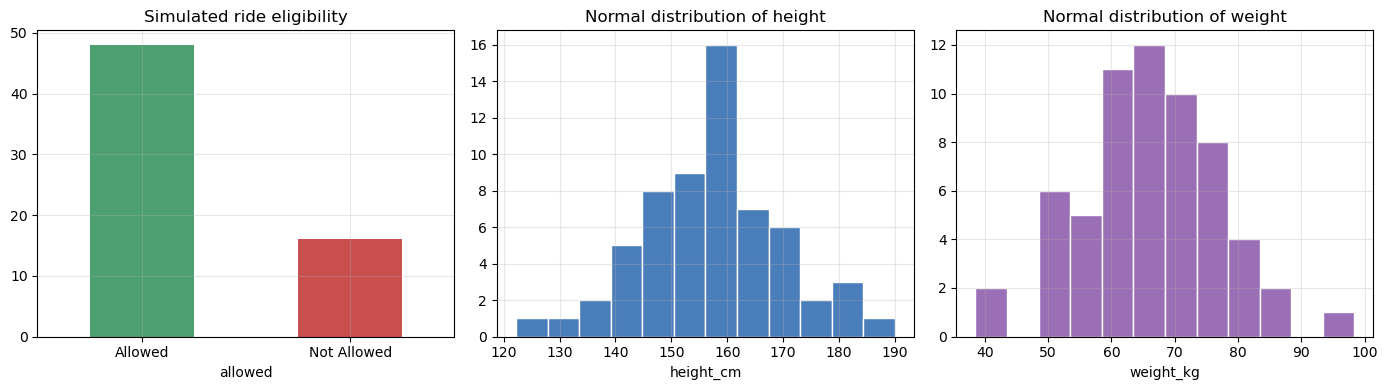

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
preview["allowed"].value_counts().reindex(["Allowed", "Not Allowed"]).plot(kind="bar", ax=axes[0], color=["#4c9f70", "#c94f4f"])
axes[0].set_title("Simulated ride eligibility"); axes[0].tick_params(axis="x", rotation=0)
axes[1].hist(df["height_cm"].dropna(), bins=12, color="#4a7ebb", edgecolor="white")
axes[1].set_title("Normal distribution of height"); axes[1].set_xlabel("height_cm")
axes[2].hist(df["weight_kg"].dropna(), bins=12, color="#9b6fb6", edgecolor="white")
axes[2].set_title("Normal distribution of weight"); axes[2].set_xlabel("weight_kg")
plt.tight_layout(); plt.show()


The two histograms are approximately bell-shaped. Mean and median should therefore be close; this is the key contrast with the skewed-data lesson.

## 3. Duplicate rows

A duplicate is a row that is *identical* to another row. Usually it is an export or merge accident, and it quietly biases every average you compute.

- `df.duplicated()` → `True` / `False` per row (the **first** occurrence is `False`)
- `df.duplicated().sum()` → how many extra copies exist
- `df.drop_duplicates()` → keep the first, throw the rest away

🎬 **See it illustrated:** step 6 — *The Same Visitor Twice* in the illustration tab.


In [11]:
print("duplicate rows:", df.duplicated().sum())

# show them
df[df.duplicated()]

duplicate rows: 4


,person,height_cm,weight_kg
60,P001,160.0,69.8
61,P002,164.5,60.5
62,P003,155.9,68.8
63,P004,146.6,50.4


In [12]:
df[df.duplicated(keep=False)].sort_values("person")

,person,height_cm,weight_kg
0,P001,160.0,69.8
60,P001,160.0,69.8
1,P002,164.5,60.5
61,P002,164.5,60.5
2,P003,155.9,68.8
62,P003,155.9,68.8
3,P004,146.6,50.4
63,P004,146.6,50.4


In [13]:
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
print(f"rows before: {before}  ->  rows after: {df.shape[0]}")

rows before: 64  ->  rows after: 60


## 4. Missing values

`NaN` = "not a number" = an empty cell. Two questions: **where** are they, and **what do we do** about them?

Common choices:

| Strategy | Code | When |
|---|---|---|
| Drop the rows | `df.dropna()` | Very few missing, or the *target* column is missing |
| Fill with the mean | `df["c"].fillna(df["c"].mean())` | Roughly symmetric numeric column |
| Fill with the median | `df["c"].fillna(df["c"].median())` | Numeric column with outliers (safer) |
| Fill with the mode | `df["c"].fillna(df["c"].mode()[0])` | Text / category column |

🎬 **See it illustrated:** step 7 — *Where Are The Holes?*, step 8 — *Drop Or Fill?* in the illustration tab.


In [14]:
# where are they?
print(df.isnull().sum())
print("\ntotal missing cells:", df.isnull().sum().sum())

person       0
height_cm    3
weight_kg    3
dtype: int64

total missing cells: 6


In [15]:
# the rows that contain at least one missing value
df[df.isnull().any(axis=1)]

,person,height_cm,weight_kg
5,P006,NaN,64.3
11,P012,165.4,NaN
18,P019,NaN,63.5
33,P034,147.9,NaN
40,P041,NaN,62.7
52,P053,161.1,NaN


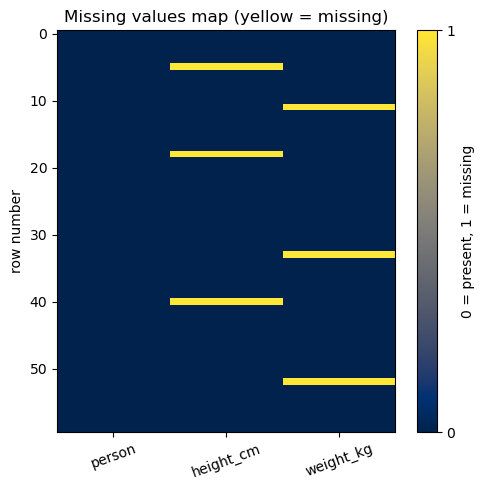

In [16]:
# a picture of the holes: yellow = missing
plt.figure(figsize=(5, 5))
plt.imshow(df.isnull(), aspect="auto", cmap="cividis", interpolation="nearest")
plt.xticks(range(df.shape[1]), df.columns, rotation=20)
plt.ylabel("row number")
plt.title("Missing values map (yellow = missing)")
plt.grid(False)
plt.colorbar(ticks=[0, 1], label="0 = present, 1 = missing")
plt.tight_layout()
plt.show()

In [17]:
# Numeric columns are approximately symmetric and normal, so use the MEAN.
for col in ["height_cm", "weight_kg"]:
    mean_value = df[col].mean()
    df[col] = df[col].fillna(mean_value)
    print(f"{col:<12} filled with mean = {mean_value:.2f}")

df["allowed"] = np.where(
    df["height_cm"].between(145, 190) & df["weight_kg"].le(90),
    "Allowed", "Not Allowed")
print("missing values left:", df.isnull().sum().sum())


height_cm    filled with mean = 157.43
weight_kg    filled with mean = 66.25
missing values left: 0


## 5. Distribution and outliers — boxplot + the IQR rule

A **boxplot** shows five numbers at once:

```
        Q1      median      Q3
   |-----[=======|==========]-----|      o     o
 lower                            upper   outliers
 whisker                          whisker
```

- **Q1** = 25th percentile, **Q3** = 75th percentile
- **IQR** = Q3 − Q1 (the width of the middle 50% of the data)
- Anything below **Q1 − 1.5 × IQR** or above **Q3 + 1.5 × IQR** is flagged as an **outlier**

That 1.5 × IQR rule is exactly what draws the dots outside the whiskers.

🎬 **See it illustrated:** step 9 — *Reading A Boxplot*, step 10 — *The 1.5 × IQR Rule*, step 11 — *After The Filter* in the illustration tab.


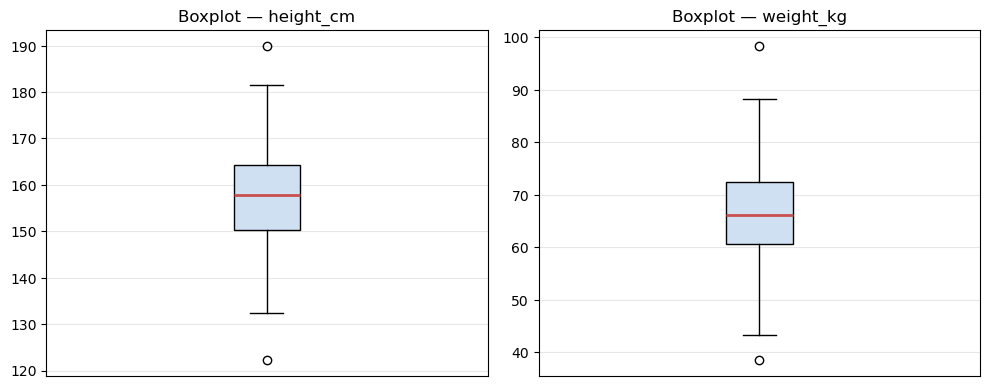

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col in zip(axes, ["height_cm", "weight_kg"]):
    ax.boxplot(df[col], patch_artist=True, boxprops=dict(facecolor="#cfe0f3"), medianprops=dict(color="#c94f4f", linewidth=2))
    ax.set_title(f"Boxplot — {col}"); ax.set_xticks([])
plt.tight_layout(); plt.show()


In [19]:
df[["height_cm", "weight_kg"]].describe().loc[["min", "25%", "50%", "mean", "75%", "max"]]

,height_cm,weight_kg
min,122.200000,38.500000
25%,150.275000,60.725000
50%,157.863158,66.075439
mean,157.426316,66.250877
75%,164.200000,72.400000
max,190.000000,98.400000


In [20]:
def iqr_bounds(series):
    q1, q3 = series.quantile([0.25, 0.75]); iqr = q3 - q1
    return q1, q3, iqr, q1 - 1.5 * iqr, q3 + 1.5 * iqr

for col in ["height_cm", "weight_kg"]:
    q1, q3, iqr, low, high = iqr_bounds(df[col])
    flagged = df[(df[col] < low) | (df[col] > high)]
    print(col, "mean", round(df[col].mean(),2), "median", round(df[col].median(),2), "IQR flags", len(flagged))


height_cm mean 157.43 median 157.86 IQR flags 2
weight_kg mean 66.25 median 66.08 IQR flags 2


In [21]:
# For this pure normal teaching dataset, inspect IQR flags but do not automatically delete valid people.
df_outliers = pd.concat([df[(df[c] < iqr_bounds(df[c])[3]) | (df[c] > iqr_bounds(df[c])[4])] for c in ["height_cm", "weight_kg"]]).drop_duplicates()
df_clean = df.copy().reset_index(drop=True)
print("rows flagged for inspection:", len(df_outliers))
print("rows retained:", len(df_clean))
df_outliers


rows flagged for inspection: 4
rows retained: 60


,person,height_cm,weight_kg,allowed
26,P027,122.2,66.8,Not Allowed
49,P050,190.0,64.1,Allowed
39,P040,158.3,38.5,Allowed
43,P044,161.1,98.4,Not Allowed


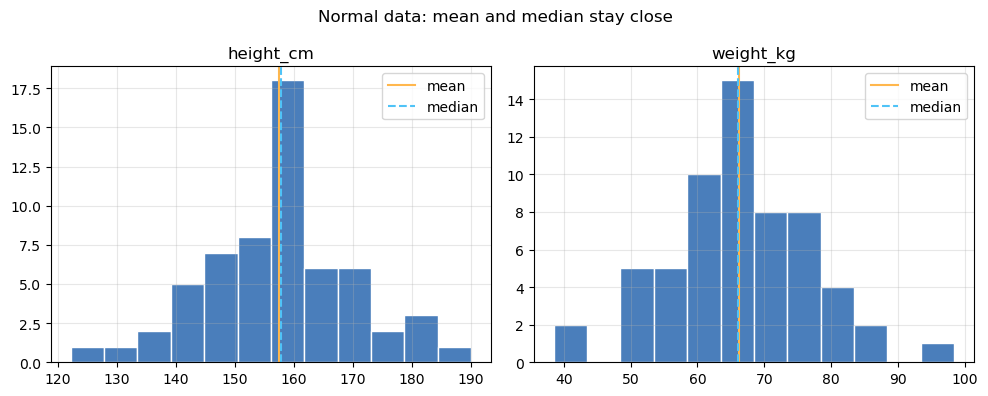

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col in zip(axes, ["height_cm", "weight_kg"]):
    ax.hist(df_clean[col], bins=12, color="#4a7ebb", edgecolor="white")
    ax.axvline(df_clean[col].mean(), color="#ffb74d", label="mean")
    ax.axvline(df_clean[col].median(), color="#4fc3f7", linestyle="--", label="median")
    ax.set_title(col); ax.legend()
plt.suptitle("Normal data: mean and median stay close"); plt.tight_layout(); plt.show()


The IQR rule may flag valid tail observations even in a normal distribution. We inspect them, but we do not delete real people merely because their measurements are uncommon.

## 6. Selecting data — `iloc` vs `loc`

This is the single most confused pair in pandas:

| | `iloc` | `loc` |
|---|---|---|
| Selects by | **position** (integer) | **label** (index / column name) |
| `0` means | the first row | the row whose index *is* `0` |
| Slice `1:4` | rows 1, 2, 3 — end **excluded** | rows 1 to 4 — end **included** |
| Conditions | ✗ | ✓ `df.loc[df["x"] > 5]` |

Memory hook: **i**loc = **i**nteger, **loc** = **l**abel.

🎬 **See it illustrated:** step 12 — *iloc — By Position*, step 13 — *loc — By Label And Condition*, step 14 — *loc That Writes* in the illustration tab.


In [23]:
# ---- iloc: everything is a POSITION ----
print("first row:")
print(df_clean.iloc[0], "\n")

print("value at row 0, column 0:", df_clean.iloc[0, 0], "\n")

print("rows 0-4, all columns:")
display(df_clean.iloc[0:5])

first row:
person          P001
height_cm      160.0
weight_kg       69.8
allowed      Allowed
Name: 0, dtype: object 

value at row 0, column 0: P001 

rows 0-4, all columns:


,person,height_cm,weight_kg,allowed
0,P001,160.0,69.8,Allowed
1,P002,164.5,60.5,Allowed
2,P003,155.9,68.8,Allowed
3,P004,146.6,50.4,Allowed
4,P005,153.2,58.9,Allowed


In [24]:
# rows 0-4, first two columns only (end position excluded on both sides)
df_clean.iloc[0:5, 0:2]

,person,height_cm
0,P001,160.0
1,P002,164.5
2,P003,155.9
3,P004,146.6
4,P005,153.2


In [25]:
# a scattered pick: specific rows AND specific columns, by position
df_clean.iloc[[0, 3, 7], [0, 2]]

,person,weight_kg
0,P001,69.8
3,P004,50.4
7,P008,83.0


In [26]:
# last 3 rows, negative positions work like Python lists
df_clean.iloc[-3:]

,person,height_cm,weight_kg,allowed
57,P058,170.0,55.0,Allowed
58,P059,181.6,80.6,Allowed
59,P060,149.9,69.7,Allowed


In [27]:
df_clean.loc[0:4, ["person", "height_cm", "weight_kg", "allowed"]]

,person,height_cm,weight_kg,allowed
0,P001,160.0,69.8,Allowed
1,P002,164.5,60.5,Allowed
2,P003,155.9,68.8,Allowed
3,P004,146.6,50.4,Allowed
4,P005,153.2,58.9,Allowed


In [28]:
df_clean.loc[df_clean["height_cm"] > 170]

,person,height_cm,weight_kg,allowed
7,P008,180.1,83.0,Allowed
15,P016,170.4,76.7,Allowed
34,P035,175.9,66.9,Allowed
37,P038,173.3,71.9,Allowed
44,P045,180.4,55.4,Allowed
46,P047,172.9,69.9,Allowed
49,P050,190.0,64.1,Allowed
50,P051,171.4,76.8,Allowed
55,P056,170.2,52.2,Allowed
58,P059,181.6,80.6,Allowed


In [29]:
eligible_tall = df_clean.loc[(df_clean["height_cm"] >= 145) & (df_clean["height_cm"] <= 190) & (df_clean["weight_kg"] <= 90)]
print("inside simulated limits:", len(eligible_tall))
eligible_tall.head()

inside simulated limits: 50


,person,height_cm,weight_kg,allowed
0,P001,160.0,69.8,Allowed
1,P002,164.5,60.5,Allowed
2,P003,155.9,68.8,Allowed
3,P004,146.6,50.4,Allowed
4,P005,153.2,58.9,Allowed


In [30]:
df_clean["allowed"] = "Allowed"
df_clean.loc[(df_clean["height_cm"] < 145) | (df_clean["height_cm"] > 190) | (df_clean["weight_kg"] > 90), "allowed"] = "Not Allowed"
df_clean["allowed"].value_counts()


allowed
Allowed        50
Not Allowed    10
Name: count, dtype: int64

In [31]:
pd.crosstab(df_clean["allowed"], columns="visitors")

col_0,visitors
allowed,
Allowed,50
Not Allowed,10


## 7. Where we ended up

🎬 **See it illustrated:** step 15 — *What The Clean Table Says* in the illustration tab.


In [32]:
summary = pd.DataFrame({"stage":["raw file","after drop_duplicates","after mean fill","final retained"],"rows":[len(df_raw),len(df_raw.drop_duplicates()),len(df),len(df_clean)]})
print(summary.to_string(index=False)); print("final missing:",df_clean.isnull().sum().sum()); print("final duplicates:",df_clean.duplicated().sum()); df_clean.describe(include="all")


                stage  rows
             raw file    64
after drop_duplicates    60
      after mean fill    60
       final retained    60
final missing: 0
final duplicates: 0


,person,height_cm,weight_kg,allowed
count,60,60.000000,60.000000,60
unique,60,NaN,NaN,2
top,P001,NaN,NaN,Allowed
freq,1,NaN,NaN,50
mean,NaN,157.426316,66.250877,NaN
std,NaN,12.809828,10.956495,NaN
min,NaN,122.200000,38.500000,NaN
25%,NaN,150.275000,60.725000,NaN
50%,NaN,157.863158,66.075439,NaN
75%,NaN,164.200000,72.400000,NaN


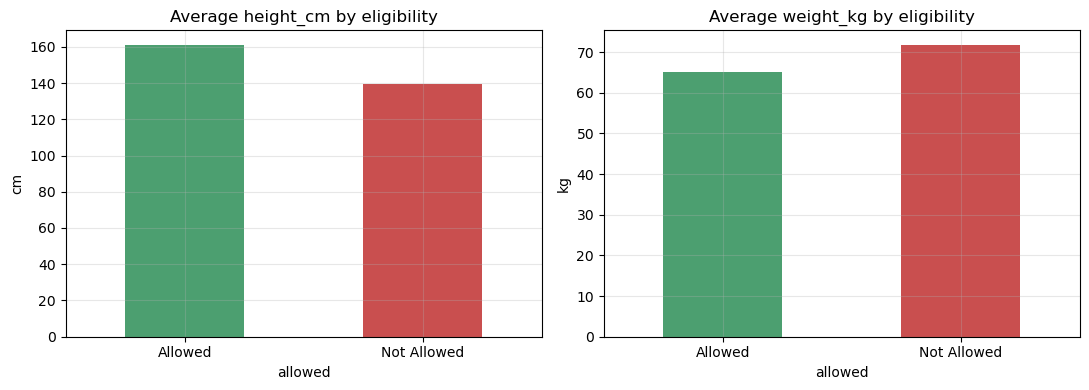

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax,col,unit in zip(axes,["height_cm","weight_kg"],["cm","kg"]):
    df_clean.groupby("allowed")[col].mean().plot(kind="bar",ax=ax,color=["#4c9f70","#c94f4f"])
    ax.set_title(f"Average {col} by eligibility"); ax.set_ylabel(unit); ax.tick_params(axis="x",rotation=0)
plt.tight_layout(); plt.show()


## 8. Your turn

1. Compare mean and median for both normal numeric columns.
2. Use `loc` to show visitors taller than 170 cm.
3. Recalculate eligibility with a different **simulated** height limit.
4. Count IQR flags without deleting them.
5. Explain why mean imputation is reasonable here but may be poor for skewed data.

🎬 **See it illustrated:** step 15 — *What The Clean Table Says* in the illustration tab.
